Notebook : 01_porto_profiling.ipynb
 TaaSim — Semaine 1 : Exploration du dataset Porto
 À exécuter dans Jupyter : http://localhost:8888

CELLULE 1 — Imports et chargement

In [1]:
from pyspark.sql import SparkSession
import os

home = os.path.expanduser("~")

spark = SparkSession.builder \
    .master("local[*]") \
    .appName("TaaSim-MinIO-Test") \
    .config("spark.jars", 
            f"{home}/hadoop-aws-3.3.4.jar,{home}/aws-java-sdk-bundle-1.12.262.jar") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://minio:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "taasim") \
    .config("spark.hadoop.fs.s3a.secret.key", "taasim123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .getOrCreate()

In [2]:
df = spark.read.csv("s3a://raw/porto-trips/train.csv", header=True, inferSchema=True)
df.show()

+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|            TRIP_ID|CALL_TYPE|ORIGIN_CALL|ORIGIN_STAND| TAXI_ID| TIMESTAMP|DAY_TYPE|MISSING_DATA|            POLYLINE|
+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------+
|1372636858620000589|        C|       null|        null|20000589|1372636858|       A|       false|[[-8.618643,41.14...|
|1372637303620000596|        B|       null|           7|20000596|1372637303|       A|       false|[[-8.639847,41.15...|
|1372636951620000320|        C|       null|        null|20000320|1372636951|       A|       false|[[-8.612964,41.14...|
|1372636854620000520|        C|       null|        null|20000520|1372636854|       A|       false|[[-8.574678,41.15...|
|1372637091620000337|        C|       null|        null|20000337|1372637091|       A|       false|[[-8.645994,41.18...|
|1372636965620000231|        C|       nu

In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
 
# Lancer Spark (local pour exploration)
spark = SparkSession.builder \
    .appName("TaaSim-Porto-Profiling") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
 
# Charger le CSV Porto (depuis MinIO ou local)
# Option A : depuis MinIO (si ton camarade a déjà uploadé)
df = spark.read.csv("s3a://raw/porto-trips/train.csv", header=True, inferSchema=True)
 
# Option B : local pour commencer vite
#df = spark.read.csv("/home/jovyan/work/data/train.csv", header=True, inferSchema=True)
 
print(f"Nombre de lignes : {df.count():,}")
print(f"Colonnes : {df.columns}")
df.printSchema()

Nombre de lignes : 1,710,670
Colonnes : ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']
root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)



 CELLULE 2 — Vue rapide sur les données

In [4]:
# Afficher 5 lignes
df.show(5, truncate=80)
 
# Statistiques descriptives
df.select("TAXI_ID", "TIMESTAMP", "MISSING_DATA").describe().show()
 
# Compter les valeurs nulles par colonne
print("\n=== VALEURS NULLES ===")
for col_name in df.columns:
    null_count = df.filter(F.col(col_name).isNull()).count()
    print(f"{col_name}: {null_count:,} nulls")

+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------------------------------------------------------------------+
|            TRIP_ID|CALL_TYPE|ORIGIN_CALL|ORIGIN_STAND| TAXI_ID| TIMESTAMP|DAY_TYPE|MISSING_DATA|                                                                        POLYLINE|
+-------------------+---------+-----------+------------+--------+----------+--------+------------+--------------------------------------------------------------------------------+
|1372636858620000589|        C|       null|        null|20000589|1372636858|       A|       false|[[-8.618643,41.141412],[-8.618499,41.141376],[-8.620326,41.14251],[-8.622153,...|
|1372637303620000596|        B|       null|           7|20000596|1372637303|       A|       false|[[-8.639847,41.159826],[-8.640351,41.159871],[-8.642196,41.160114],[-8.644455...|
|1372636951620000320|        C|       null|        null|20000320|1372636951|       A|       false|[[

CELLULE 3 — Analyse CALL_TYPE (A/B/C)

+---------+------+
|CALL_TYPE| count|
+---------+------+
|        B|817881|
|        C|528019|
|        A|364770|
+---------+------+



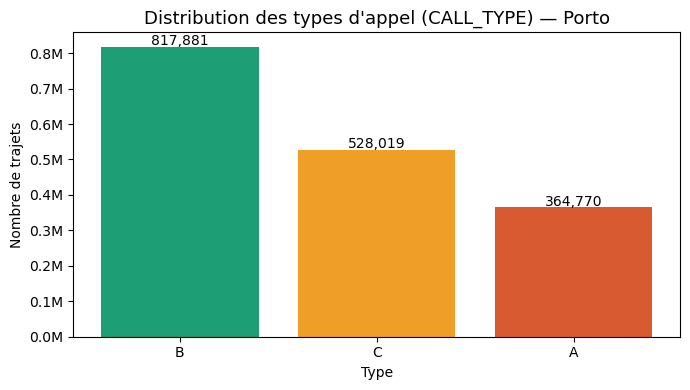

Graphe sauvegardé


In [5]:
# A = dispatché par centrale (comme Careem/Uber)
# B = pris à une station de taxis
# C = hélé dans la rue (comme les grands taxis à Casa)
 
call_type_dist = df.groupBy("CALL_TYPE").count().orderBy("count", ascending=False)
call_type_dist.show()
 
# Visualisation
call_pdf = call_type_dist.toPandas()
fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#1D9E75", "#EF9F27", "#D85A30"]
bars = ax.bar(call_pdf["CALL_TYPE"], call_pdf["count"], color=colors)
ax.set_title("Distribution des types d'appel (CALL_TYPE) — Porto", fontsize=13)
ax.set_xlabel("Type")
ax.set_ylabel("Nombre de trajets")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, val in zip(bars, call_pdf["count"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
            f"{val:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("/home/jovyan/work/notebooks/image/call_type_distribution.png", dpi=150)
plt.show()
print("Graphe sauvegardé")

CELLULE 4 — Courbe de demande temporelle

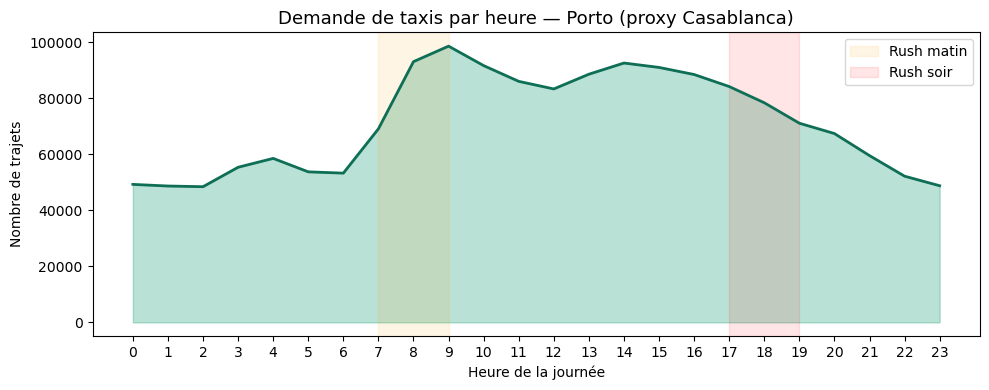

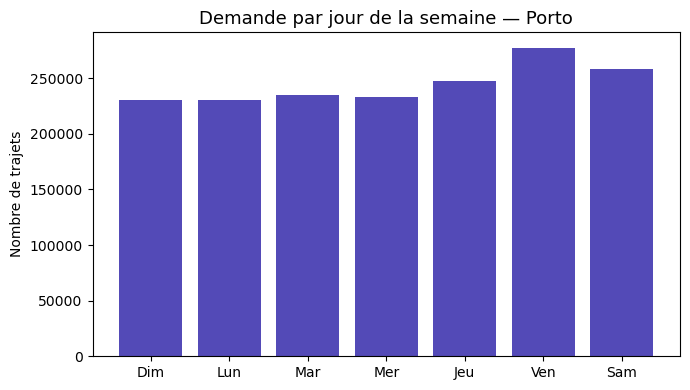

In [6]:
# C'est la courbe la plus importante : elle servira au simulateur trip_request_producer.py
 
from pyspark.sql.functions import from_unixtime, hour, dayofweek
 
df_time = df.withColumn("datetime", from_unixtime(F.col("TIMESTAMP"))) \
            .withColumn("hour_of_day", hour("datetime")) \
            .withColumn("day_of_week", dayofweek("datetime"))  # 1=Dimanche, 7=Samedi
 
# Demande par heure de la journée
hourly = df_time.groupBy("hour_of_day").count().orderBy("hour_of_day").toPandas()
 
fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(hourly["hour_of_day"], hourly["count"], alpha=0.3, color="#1D9E75")
ax.plot(hourly["hour_of_day"], hourly["count"], color="#0F6E56", linewidth=2)
ax.set_title("Demande de taxis par heure — Porto (proxy Casablanca)", fontsize=13)
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Nombre de trajets")
ax.set_xticks(range(0, 24))
ax.axvspan(7, 9, alpha=0.1, color="orange", label="Rush matin")
ax.axvspan(17, 19, alpha=0.1, color="red", label="Rush soir")
ax.legend()
plt.tight_layout()
plt.savefig("/home/jovyan/work/notebooks/image/hourly_demand.png", dpi=150)
plt.show()
 
# Demande par jour de la semaine
daily = df_time.groupBy("day_of_week").count().orderBy("day_of_week").toPandas()
jours = ["Dim", "Lun", "Mar", "Mer", "Jeu", "Ven", "Sam"]
daily["jour"] = [jours[d-1] for d in daily["day_of_week"]]
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(daily["jour"], daily["count"], color="#534AB7")
ax.set_title("Demande par jour de la semaine — Porto", fontsize=13)
ax.set_ylabel("Nombre de trajets")
plt.tight_layout()
plt.savefig("/home/jovyan/work/notebooks/image/weekly_demand.png", dpi=150)
plt.show()

CELLULE 5 — Durée des trajets

+-------+------------------+
|summary|      duration_min|
+-------+------------------+
|  count|           1710660|
|   mean| 12.18950828919832|
| stddev|11.413060865214096|
|    min|               0.0|
|    max|            970.25|
+-------+------------------+



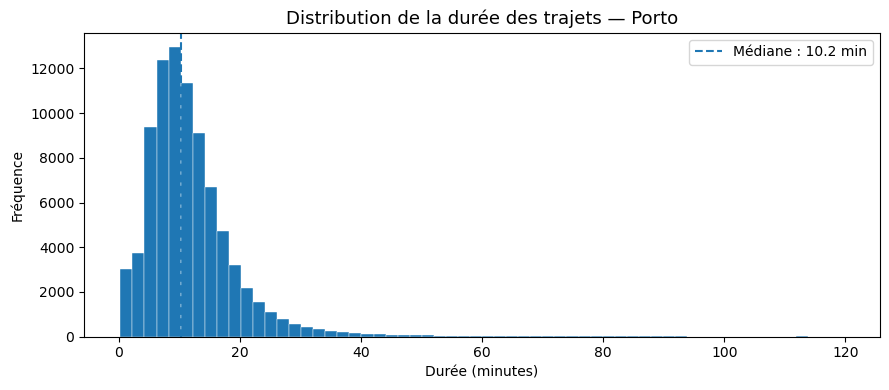

In [8]:
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.sql.types import ArrayType, DoubleType

# Filtrer les trajets valides + calcul durée
df_dur = df.filter(F.col("MISSING_DATA") == "False") \
    .withColumn(
        "polyline_len",
        F.size(
            F.from_json(
                F.col("POLYLINE"),
                ArrayType(ArrayType(DoubleType()))
            )
        )
    ) \
    .withColumn("duration_min", F.col("polyline_len") * 15 / 60)

# Statistiques
stats = df_dur.select("duration_min").describe()
stats.show()

# Conversion en pandas (échantillon)
dur_pdf = df_dur.filter(
    (F.col("duration_min") > 0) & (F.col("duration_min") < 120)
).select("duration_min").sample(0.05).toPandas()

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(dur_pdf["duration_min"], bins=60, edgecolor="white", linewidth=0.3)
ax.set_title("Distribution de la durée des trajets — Porto", fontsize=13)
ax.set_xlabel("Durée (minutes)")
ax.set_ylabel("Fréquence")

median_val = dur_pdf["duration_min"].median()
ax.axvline(median_val, linestyle="--",
           label=f"Médiane : {median_val:.1f} min")

ax.legend()
plt.tight_layout()

# ⚠️ vérifier que le dossier existe
import os
os.makedirs("/home/jovyan/work/notebooks/image", exist_ok=True)

plt.savefig("/home/jovyan/work/notebooks/image/trip_duration.png", dpi=150)
plt.show()

CELLULE 6 — Analyse des taxis actifs

Nombre de taxis uniques : 448
+--------+-----+
| TAXI_ID|trips|
+--------+-----+
|20000080|10746|
|20000403| 9238|
|20000066| 8449|
|20000364| 7821|
|20000483| 7729|
|20000129| 7609|
|20000307| 7498|
|20000621| 7276|
|20000089| 7267|
|20000424| 7176|
+--------+-----+
only showing top 10 rows



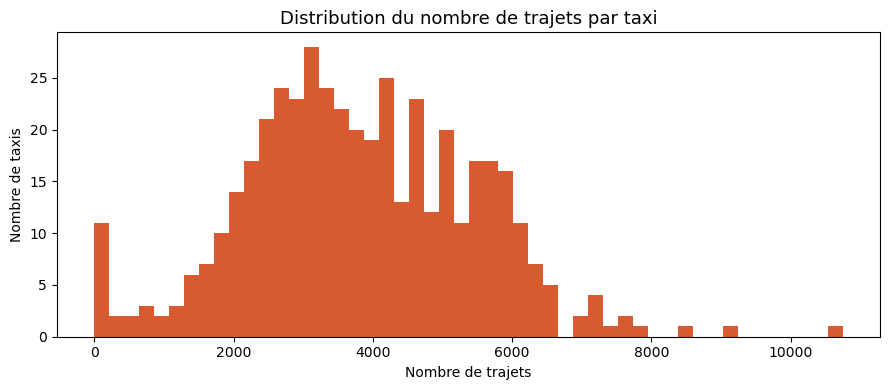

In [9]:
# Combien de taxis uniques ? Quelle activité par taxi ?
 
n_taxis = df.select("TAXI_ID").distinct().count()
print(f"Nombre de taxis uniques : {n_taxis}")
 
trips_per_taxi = df.groupBy("TAXI_ID").count() \
                   .withColumnRenamed("count", "trips") \
                   .orderBy("trips", ascending=False)
 
trips_per_taxi.show(10)
trips_pdf = trips_per_taxi.toPandas()
 
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(trips_pdf["trips"], bins=50, color="#D85A30")
ax.set_title("Distribution du nombre de trajets par taxi", fontsize=13)
ax.set_xlabel("Nombre de trajets")
ax.set_ylabel("Nombre de taxis")
plt.tight_layout()
plt.savefig("/home/jovyan/work/notebooks/image/trips_per_taxi.png", dpi=150)
plt.show()

CELLULE 7 — Données manquantes (MISSING_DATA)

In [10]:
missing = df.groupBy("MISSING_DATA").count()
missing.show()
 
total = df.count()
n_missing = df.filter(F.col("MISSING_DATA") == "True").count()
print(f"Trajets incomplets : {n_missing:,} ({n_missing/total*100:.1f}%)")
print(f"À supprimer lors de l'ETL Spark (Semaine 5)")

+------------+-------+
|MISSING_DATA|  count|
+------------+-------+
|        true|     10|
|       false|1710660|
+------------+-------+

Trajets incomplets : 10 (0.0%)
À supprimer lors de l'ETL Spark (Semaine 5)


RÉSUMÉ POUR LE RAPPORT

In [11]:
print("""
=== RÉSUMÉ DATASET PORTO ===
- Lignes totales     : ~1.7 million de trajets
- Période            : Juillet 2013 – Juin 2014
- Taxis distincts    : 442
- CALL_TYPE A        : dispatché (≈ 30%)
- CALL_TYPE B        : station (≈ 30%)
- CALL_TYPE C        : rue (≈ 40%)
- Rush matin         : 7h–9h
- Rush soir          : 17h–19h
- Durée médiane      : ~15–20 minutes
- MISSING_DATA True  : ~1% à filtrer
""")


=== RÉSUMÉ DATASET PORTO ===
- Lignes totales     : ~1.7 million de trajets
- Période            : Juillet 2013 – Juin 2014
- Taxis distincts    : 442
- CALL_TYPE A        : dispatché (≈ 30%)
- CALL_TYPE B        : station (≈ 30%)
- CALL_TYPE C        : rue (≈ 40%)
- Rush matin         : 7h–9h
- Rush soir          : 17h–19h
- Durée médiane      : ~15–20 minutes
- MISSING_DATA True  : ~1% à filtrer

